# Regression -  Neural Network

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
path = "./dataset/house-prices/houses.csv"
dataset = pd.read_csv(path)

In [3]:
dataset.drop('Id', inplace=True, axis=1)
dataset[0:15]

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,65.0,8450,7,5,2003,3,8,208500
1,80.0,9600,6,8,1976,3,6,181500
2,68.0,11250,7,5,2001,3,6,223500
3,60.0,9550,7,5,1915,3,7,140000
4,84.0,14260,8,5,2000,4,9,250000
5,85.0,14115,5,5,1993,1,5,143000
6,75.0,10084,8,5,2004,3,7,307000
7,NaN,10382,7,6,1973,3,7,200000
8,51.0,6120,7,5,1931,2,8,129900
9,50.0,7420,5,6,1939,2,5,118000


In [4]:
# removing elements with Missing Data
dataset.dropna(axis=0, inplace=True)
dataset[0:15]

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,65.0,8450,7,5,2003,3,8,208500
1,80.0,9600,6,8,1976,3,6,181500
2,68.0,11250,7,5,2001,3,6,223500
3,60.0,9550,7,5,1915,3,7,140000
4,84.0,14260,8,5,2000,4,9,250000
5,85.0,14115,5,5,1993,1,5,143000
6,75.0,10084,8,5,2004,3,7,307000
8,51.0,6120,7,5,1931,2,8,129900
9,50.0,7420,5,6,1939,2,5,118000
10,70.0,11200,5,5,1965,3,5,129500


In [5]:
print(dataset.columns.values)

['LotFrontage' 'LotArea' 'OverallQual' 'OverallCond' 'YearBuilt'
 'BedroomAbvGr' 'TotRmsAbvGrd' 'SalePrice']


In [6]:
y = dataset['SalePrice']

X = dataset.copy()
X.drop('SalePrice', inplace=True, axis=1)

print(y[:5])
print(X[:5])

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64
   LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
0         65.0     8450            7            5       2003             3   
1         80.0     9600            6            8       1976             3   
2         68.0    11250            7            5       2001             3   
3         60.0     9550            7            5       1915             3   
4         84.0    14260            8            5       2000             4   

   TotRmsAbvGrd  
0             8  
1             6  
2             6  
3             7  
4             9  


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size = 0.3,
    random_state=10
)
print(len(dataset))
print(len(X_train))
print(len(X_test))

1201
840
361


### Scaling the data

In [8]:
from sklearn.preprocessing import StandardScaler

print("Original values:")
print(X_train[:2])
print(X_test[:2])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nScaled values:")
print(X_train[:2])
print(X_test[:2])

Original values:
     LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
750         55.0     8800            4            7       1910             3   
542         78.0    10140            7            5       1998             3   

     TotRmsAbvGrd  
750             7  
542             7  
      LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  BedroomAbvGr  \
148          63.0     7500            7            5       2004             3   
1313        108.0    14774            9            5       1999             4   

      TotRmsAbvGrd  
148              6  
1313            10  

Scaled values:
[[-0.59343374 -0.1345642  -1.50163769  1.32077067 -1.94355278  0.17004777
   0.28779232]
 [ 0.33072714  0.01790758  0.61239973 -0.5252316   0.86970448  0.17004777
   0.28779232]]
[[-0.27198648 -0.28248458  0.61239973 -0.5252316   1.06151747  0.17004777
  -0.33687319]
 [ 1.53615437  0.54518683  2.02175801 -0.5252316   0.90167331  1.40142814
   2.16178885]]


In [9]:
model = Sequential ([
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [10]:
model.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(0.01),
    metrics=['mae', 'mse']
)
#MAE - MEAN ABS ERROR
#MAE = (1/n) * Σ|ACTUAL – PREDICTED|

#MSE - MEAN SQUARED ERROR
#MSE = (1/n) * Σ(Actual - predicted)^2

In [11]:
model.fit(
    X_train, y_train,
    epochs=60,
    batch_size = 32
)

Epoch 1/60
27/27 [==============================] - 1s 1ms/step - loss: 40263626752.0000 - mae: 181618.0156 - mse: 40263626752.0000
Epoch 2/60
27/27 [==============================] - 0s 1ms/step - loss: 40237584384.0000 - mae: 181559.6250 - mse: 40237584384.0000
Epoch 3/60
27/27 [==============================] - 0s 1ms/step - loss: 40108339200.0000 - mae: 181279.2500 - mse: 40108339200.0000
Epoch 4/60
27/27 [==============================] - 0s 1ms/step - loss: 39737696256.0000 - mae: 180483.2344 - mse: 39737696256.0000
Epoch 5/60
27/27 [==============================] - 0s 1ms/step - loss: 38932254720.0000 - mae: 178769.5781 - mse: 38932254720.0000
Epoch 6/60
27/27 [==============================] - 0s 1ms/step - loss: 37502169088.0000 - mae: 175710.8125 - mse: 37502169088.0000
Epoch 7/60
27/27 [==============================] - 0s 1ms/step - loss: 35304194048.0000 - mae: 170812.3750 - mse: 35304194048.0000
Epoch 8/60
27/27 [==============================] - 0s 1ms/step - loss: 3224

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                128       
                                                                 
 dense_1 (Dense)             (None, 32)                544       
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 705
Trainable params: 705
Non-trainable params: 0
_________________________________________________________________


In [13]:
predictions = model.predict(X_test)

12/12 [==============================] - 0s 596us/step


In [14]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Root mean square error: {rmse}")


Root mean square error: 41859.828571077545


In [18]:
print("predictions\n", predictions[:10])

print("nCurrents\n", y_test[:10])

predictions
 [[202103.66 ]
 [376322.16 ]
 [110241.336]
 [143251.   ]
 [173559.62 ]
 [ 82081.47 ]
 [278271.34 ]
 [109449.73 ]
 [ 88242.61 ]
 [274954.88 ]]
nCurrents
 148     141000
1313    333168
1252    130000
513     134000
920     201000
609     118500
583     325000
79      110000
1125    115000
700     312500
Name: SalePrice, dtype: int64


12/12 [==============================] - 0s 2ms/step


[]

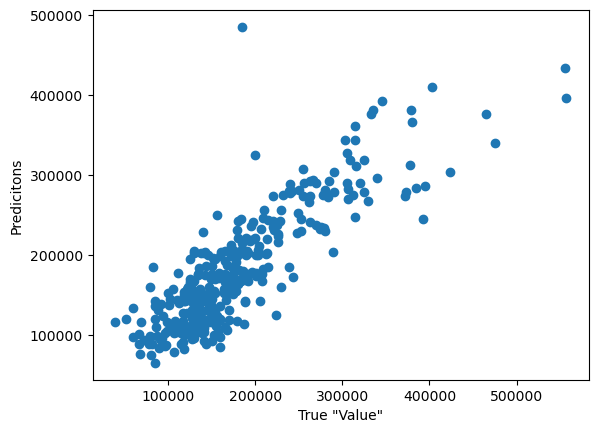

In [19]:
test_predictions = model.predict(X_test).flatten()
plt.scatter(y_test, test_predictions)
plt.xlabel('True "Value"')
plt.ylabel('Predicitons')

plt.plot()

[]

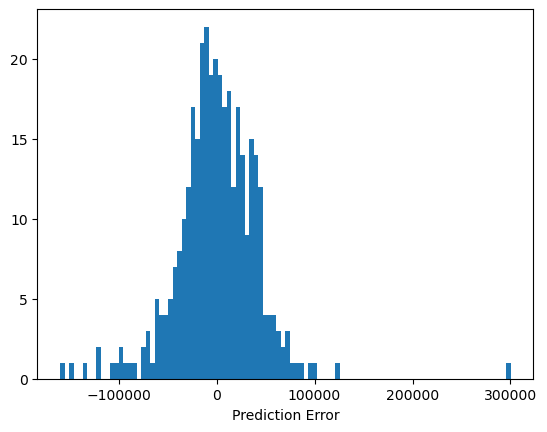

In [20]:
error = test_predictions - y_test
plt.hist(error, bins = 100)
plt.xlabel("Prediction Error")
plt.plot()